In [1]:
from collections.abc import Callable
from pathlib import Path
from typing import Any, Literal

import equinox as eqx
import jax
import xarray as xr
from context_flux_no.simulations.pde import CubicFlux1D
from context_flux_no.waveforms.grf import (
    GaussianRandomField1D,
    PeriodicCov,
)
from jaxtyping import Array, PRNGKeyArray
from tqdm import tqdm


jax.config.update("jax_enable_x64", True)


INFO:2025-11-05 18:47:18,860:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-11-05 18:47:18,860 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [2]:
def sample_pde(
    pde_factory: Callable[[Any], eqx.Module],
    *,
    seed: int = 0,
    **kwargs: dict[str, tuple[float, float]],
) -> eqx.Module:
    keys = jax.random.split(jax.random.key(seed), len(kwargs))

    param_dict = dict()
    for rng_key, (param_name, sample_range) in zip(keys, kwargs.items()):
        param_dict[param_name] = float(
            jax.random.uniform(
                rng_key,
                minval=sample_range[0],
                maxval=sample_range[1],
            )
        )

    return pde_factory(**param_dict)

In [3]:
def sample_coefficients_uniform(
    key: PRNGKeyArray, coeff_range_dict: dict[str, tuple[float, float]]
):
    subkeys = jax.random.split(key, len(coeff_range_dict))
    return {
        name: float(
            jax.random.uniform(subkey, minval=coeff_range[0], maxval=coeff_range[1])
        )
        for subkey, (name, coeff_range) in zip(subkeys, coeff_range_dict.items())
    }


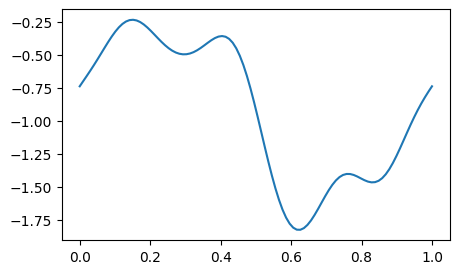

In [4]:
import jax.numpy as jnp
import matplotlib.pyplot as plt


x = jnp.linspace(0, 1, 100)
grf = GaussianRandomField1D(PeriodicCov(corr_length=1.0))
u0 = grf.sample(x, jax.random.key(10))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0)

In [5]:
def generate_dataset(
    n_coeffs: int,
    n_ics_per_coeff: int,
    pde_factory: Callable[[Any], eqx.Module],
    initial_condition_fn: Callable[[Array, PRNGKeyArray], Array],
    coeff_range_dict: dict,
    x_span: tuple[float, float],
    Nx: int,
    t_span: tuple[float, float],
    Nt: int,
    bc: Literal["periodic"] = "periodic",
    seed: int = 0,
):
    keys = jax.random.split(jax.random.key(seed), n_coeffs)

    solutions_all = []
    for key in tqdm(keys):
        key_coeff, *key_ics = jax.random.split(key, n_ics_per_coeff + 1)
        coeffs = sample_coefficients_uniform(key_coeff, coeff_range_dict)
        pde = pde_factory(**coeffs)

        solutions = []
        for key_ic in key_ics:
            sol = pde.solve_pyclaw(
                lambda u0: initial_condition_fn(u0, key_ic),
                x_span,
                Nx,
                t_span,
                Nt,
                bc,
                verbose=False,
            )
            solutions.append(sol)

        solutions_all.append(xr.concat(solutions, "ic", data_vars="minimal"))
    return xr.concat(solutions_all, "pde")

In [ ]:
dataset = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=100,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=1000,
    seed=0,
)


 53%|█████▎    | 53/100 [54:25<47:32, 60.70s/it]  

In [ ]:
dataset

<xarray.Dataset> Size: 801MB
Dimensions:  (pde: 100, ic: 10, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 801MB -0.1115 -0.1172 ... 0.7864
    coeffs   (pde, param) float64 2kB -0.4814 -0.2967 0.5484 ... -0.1377 0.806

In [ ]:
savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "cubic_no_source_large_train.hdf5")

In [5]:
dataset_test = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=10,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=1000,
    seed=1,
)

savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset_test.to_netcdf(savedir / "cubic_no_source_test.hdf5")

100%|██████████| 100/100 [09:11<00:00,  5.51s/it]
